# Transformer

In this notebook, we explain how the transformer architecture works, as introduced in the paper *[Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762)*. For some implementation in Pytrhce we followed examples and methodology from the book [*Hands-On Machine Learning With Scikit-Learn and PyTorch*](https://www.oreilly.com/library/view/hands-on-machine-learning/9798341607972/) by Aurélien Géron.

## Aim

The transformer was introduced in the context of developing machine learning models capable of solving the following problem:

> Given a sequence of input vectors, predict the most likely next element in the sequence.

In practice, transformers are most commonly used for text generation. In this setting, the vectors represent *tokens* (i.e., units into which a sentence is segmented).

The transformer architecture improves upon the previous state of the art, namely recurrent neural networks (RNNs).

---

## Recurrent Neural Networks

A recurrent neural network operates as follows. Consider a sequence of vectors $(x_1, \dots, x_t, \dots x_n)$, which are processed sequentially.

For a multi-layer RNN, the hidden states satisfy the recurrence:
$$
h_t^{(l)} = \sigma\left(W_h^{(l)} h_{t-1}^{(l)} + W_x^{(l)} h_t^{(l-1)} + b^{(l)}\right),
$$
with the convention that
$$
h_t^{(0)} = x_t.
$$

Here:

* the superscript $l$ denotes the layer,
* the subscript $t$ denotes the position in the sequence,
* $\sigma$ is an activation function,
* $W_h^{(l)}$ and $W_x^{(l)}$ are weight matrices,
* $b^{(l)}$ is the bias vector.

A key limitation of this architecture is its sequential nature. For a fixed layer $l$, before computing the representation of the last element $h_n^{(l)}$, the model must process all preceding elements $h_1^{(l)}, \dots, h_{n-1}^{(l)}$. This makes computation inherently slow, as it cannot be parallelized across time steps.

Moreover, to capture dependencies between elements separated by a distance $t$, the model requires $\mathcal{O}(t)$ sequential steps. This is referred to as the *maximal path length*.

The transformer alleviates this limitation by reducing the maximal path length to $\mathcal{O}(1)$, through the introduction of a mechanism called *self-attention*, which allows each element in the sequence to directly interact with all others. We explain this next when discussing the architecture of the transformer.


## Transformer architecture

The transformer has an encoder-decoder architecture (See the schematic below.)

* **Encoder**: processes the input sequence and builds a contextual representation of each token using self-attention and feed-forward layers, allowing each token to incorporate information from the entire input sequence.

* **Decoder**: generates the output sequence one token at a time, using masked self-attention over previously generated tokens and cross-attention over the encoder’s output representations.

---

### Encoder layer

Each encoder layer is composed of the following sublayers:

* **Multi-Head Attention**: computes attention across multiple representation subspaces (“heads”) (see next section for details).

* **Feed-Forward Network**: a position-wise two-layer perceptron:
  $$
  \text{FFN}(h) = \text{ReLU}(h W_1 + b_1) W_2 + b_2
  $$

After each sublayer, we apply an **Add & Norm** operation:

* **Add & Norm**: given an input $h$, we apply a residual connection followed by layer normalization:
  $$
  h \mapsto \text{LayerNorm}\big(h + \text{SubLayer}(h)\big)
  $$

This helps stabilize training and improves gradient flow (see a later section for details).

---

### Decoder layer

The decoder is similar to the encoder, with two key differences:

* It includes an additional **Multi-Head Attention** sublayer that performs **cross-attention**, allowing the decoder to attend to the encoder outputs.

* The first attention sublayer is **masked** to enforce causality: when predicting the token at position $t$, the model cannot access tokens at positions greater than $t$.

#### Input shifting

The input to the decoder is the target sequence shifted to the right.

For example, consider the sentence:

> ``I like eating ice cream''

Suppose it is tokenized as:
$$
[\text{``I''}, \text{``like''}, \text{``eat''}, \text{``\#\#ing''}, \text{``ice''}, \text{``cream''}, \text{``<EOS>''}]
$$

where $\text{``\#\#''}$ in  $\text{``\#\#ing''}$ means that $\text{``ing''}$ is attached to the previous token (i.e. it's a suffix).

The decoder input becomes:
$$
[\text{``<BOS>''}, \text{``I''}, \text{``like''}, \text{``eat''}, \text{``\#\#ing''}, \text{``ice''}, \text{``cream''}]
$$

The training target is:
$$
[\text{``I''}, \text{``like''}, \text{``eat''}, \text{``\#\#ing''}, \text{``ice''}, \text{``cream''}, \text{``<EOS>''}]
$$

This shift ensures that at each position the model learns to predict the next token. For instance:

- given $\text{<BOS>}$ $\rightarrow$ predict $\text{I}$
- given $\text{<BOS>}, \text{I}$ $\rightarrow$ predict $\text{like}$
- and so on


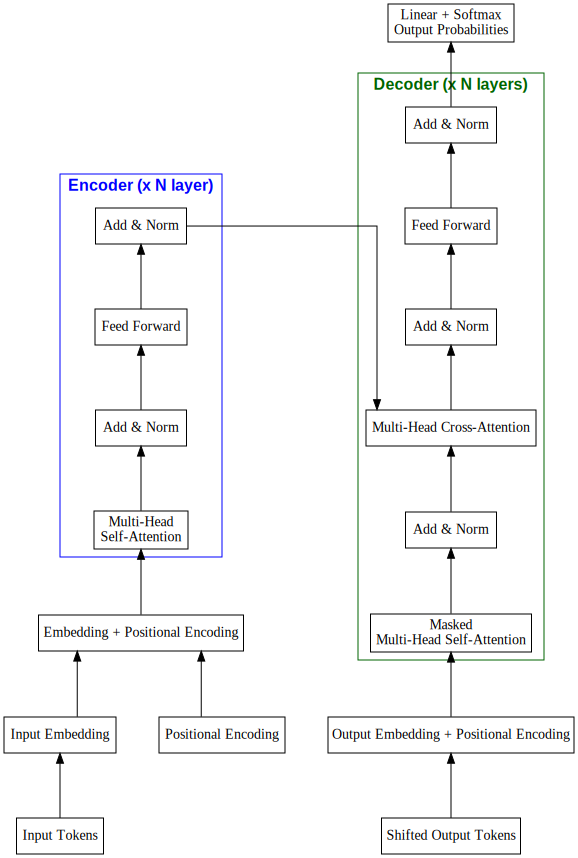

In [1]:
from graphviz import Digraph

dot = Digraph("Transformer_Fig1_Fixed", format="svg")

# Global layout tuning (important for clean arrows)
dot.attr(rankdir="BT", splines="ortho", nodesep="0.6", ranksep="0.9")

# ======================
# INPUT
# ======================
dot.node("X", "Input Tokens", shape="box")
dot.node("E", "Input Embedding", shape="box")
dot.node("PE", "Positional Encoding", shape="box")
dot.node("XPE", "Embedding + Positional Encoding", shape="box")

dot.edge("X", "E")
dot.edge("E", "XPE")
dot.edge("PE", "XPE")

# ======================
# ENCODER (×N)
# ======================
with dot.subgraph(name="cluster_encoder") as enc:
    
    enc.attr(
    label="Encoder (x N layer)",
    labelloc="b",
    fontsize="16",
    fontname="Helvetica-Bold",
    color = "blue",
    fontcolor = "blue"
    )

    enc.node("E_MHA", "Multi-Head\nSelf-Attention", shape="box")
    enc.node("E_ADD1", "Add & Norm", shape="box")
    enc.node("E_FF", "Feed Forward", shape="box")
    enc.node("E_ADD2", "Add & Norm", shape="box")

    enc.edge("E_MHA", "E_ADD1")
    enc.edge("E_ADD1", "E_FF")
    enc.edge("E_FF", "E_ADD2")

# ======================
# DECODER INPUT
# ======================
dot.node("Y", "Shifted Output Tokens", shape="box")
dot.node("YEMB", "Output Embedding + Positional Encoding", shape="box")

dot.edge("Y", "YEMB")

# ======================
# DECODER (×N)
# ======================
with dot.subgraph(name="cluster_decoder") as dec:
    dec.attr(label="Decoder (x N layers)",
    labelloc="b",
    fontsize="16",
    fontname="Helvetica-Bold",
    color = "darkgreen",
    fontcolor = "darkgreen")

    dec.node("D_MH1", "Masked\nMulti-Head Self-Attention", shape="box")
    dec.node("D_ADD1", "Add & Norm", shape="box")

    dec.node("D_MH2", "Multi-Head Cross-Attention", shape="box")
    dec.node("D_ADD2", "Add & Norm", shape="box")

    dec.node("D_FF", "Feed Forward", shape="box")
    dec.node("D_ADD3", "Add & Norm", shape="box")

    dec.edge("D_MH1", "D_ADD1")
    dec.edge("D_ADD1", "D_MH2")
    dec.edge("D_MH2", "D_ADD2")
    dec.edge("D_ADD2", "D_FF")
    dec.edge("D_FF", "D_ADD3")

# ======================
# OUTPUT
# ======================
dot.node("OUT", "Linear + Softmax\nOutput Probabilities", shape="box")

# ======================
# CONNECTIONS (IMPORTANT)
# ======================

# Encoder input flow
dot.edge("XPE", "E_MHA")

# Decoder input flow
dot.edge("YEMB", "D_MH1")

# Cross-attention (encoder → decoder middle block)
dot.edge("E_ADD2", "D_MH2", constraint="false")

# Output flow
dot.edge("D_ADD3", "OUT")

# ======================
# RENDER
# ======================
dot

## Attention

In this section, we discuss the attention mechanism which is a core sublayer of both the encoder and decoder.

### Self-Attention

The idea is the following, we introduce  three matrices (for each layer):

* K: key matrix
* Q: query matrix
* V: value matrix

These matrices are defined as follows. First, consider a sequence with $n$ tokens, then we define:

$$
k_t = x_{t}W_{K}
$$

$$
q_t = x_{t}W_{Q}
$$

$$
v_t = x_{t}W_{V}
$$

where $W_{K}, W_{Q}, W_{V}$ are learned matrices of size $d_{\text{model}} \times d_K$, $d_{\text{model}} \times d_Q$, $d_{\text{model}} \times d_V$ where $d_{\text{model}}$ is the embedding dimension. We use the convention that $x_t$ is the row vector representing the embeddign of the $t$-th token in the sequence.

We then stack these vectors $\{k_{t}\}_{t=1}^{L}$, $\{q_{t}\}_{t=1}^{L}$, $\{v_{t}\}_{t=1}^{L}$ into matrices ($L$ is the sequence length):


$$
K =
\begin{pmatrix}
k_1 \\
k_2 \\
\vdots \\
k_L
\end{pmatrix} = XW_K
\qquad
Q =
\begin{pmatrix}
q_1 \\
q_2 \\
\vdots \\
q_L
\end{pmatrix} = XW_Q
\qquad
V =
\begin{pmatrix}
v_1 \\
v_2 \\
\vdots \\
v_L
\end{pmatrix} = XW_V
$$

where 

$$
X = \begin{pmatrix}
x_1 \\
x_2 \\
\vdots \\
x_L
\end{pmatrix}
$$


The matrices $K,Q,V$ have size $L \times d_K$, $L \times d_Q$ and $L \times d_V$, where $d_K,d_Q,d_V$ are the dimensions of the projected key, query, and value representations, respectively.
We now need a mechanism to couple tokens from different positions in the sequence. The idea is to compute the similarity between a query $q_i$ and a key $k_j$ for all pairs $(i,j)$.

The components have the following interpretation:

- **Key**: represents the information content of each token  
- **Query**: represents what we are looking for  
- **Value**: represents the information we extract once a match is found  

We define the similarity scores as:
$$
S_{ij} = q_i \cdot k_j
$$

and the full score matrix can be written compactly as:
$$
S = QK^{\top}
$$

For this matrix multiplication to be well-defined, we require $d_Q = d_K$, and the resulting matrix has size $L \times L$: $QK^{\top} \in \mathbb{R}^{L \times L}$.

In practice, we scale the dot product by $1/\sqrt{d_K}$ to prevent the values from growing too large. To see why, consider:
$$
q_i \cdot k_j = \sum_{m=1}^{d_K} q_{im} k_{jm}
$$

If we assume $q_{im}$ and $k_{jm}$ are i.i.d. random variables with mean $0$ and variance $1$, then:
$$
\mathrm{Var}(q_i \cdot k_j) = d_K
$$

Hence, dividing by $\sqrt{d_K}$ normalizes the variance to approximately $1$.

#### Softmax

We now convert similarity scores into weights. The output associated with query $q_i$ is a weighted sum of values:
$$
\text{output}_i = \sum_{j=1}^{L} p_{ij} v_j
$$

where $p_{ij}$ should be large when $q_i$ aligns strongly with $k_j$, and small otherwise.

We normalize the scores using the softmax function:
$$
p_{ij} = \text{softmax}_j(S_{ij}) \equiv \frac{\exp(S_{ij})}{\sum_{k=1}^{L} \exp(S_{ik})}
$$

The subscript $j$ indicates normalization over the second index (row-wise softmax), ensuring:
$$
\sum_{j=1}^{L} p_{ij} = 1
$$

Thus, the attention mechanism becomes:
$$
\text{Attention}_i = \sum_{j=1}^{L} \text{softmax}_j(q_i \cdot k_j)\, v_j
$$

In matrix form:
$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^{\top}}{\sqrt{d_K}}\right)V
$$

where softmax is applied row-wise to the matrix. In this case, the self-attention is a matrix of size $\text{Attention}(Q, K, V) \in \mathbb{R}^{L \times d_V}$.

---

### Multi-Head Attention

In the transformer architecture, we use **multi-head attention (MHA)**. This is defined, for $h$ heads, as:

$$
\text{MHA}(H_1, \dots, H_h) = \text{Concat}(H_1, \dots, H_h) W_O
$$

where each head is given by:

$$
H_i = \text{Attention}(Q_i, K_i, V_i)
$$

and the projections are:

$$
Q_i = X W_{Q,i}, \qquad K_i = X W_{K,i}, \qquad V_i = X W_{V,i}.
$$


#### Dimensions

The projection matrices produce:

- $K_i \in \mathbb{R}^{L \times d_k}$
- $Q_i \in \mathbb{R}^{L \times d_k}$
- $V_i \in \mathbb{R}^{L \times d_v}$

Each attention head therefore has output:

$$
H_i \in \mathbb{R}^{L \times d_v}.
$$

Concatenating along the feature dimension gives:

$$
\text{Concat}(H_1, \dots, H_h) \in \mathbb{R}^{L \times (h d_v)}.
$$

Finally, the output projection matrix $W_O$ maps back to the model dimension:

$$
W_O \in \mathbb{R}^{(h d_v) \times d_{\text{model}}}
$$

so that:

$$
\text{MHA}(H_1, \dots, H_h) \in \mathbb{R}^{L \times d_{\text{model}}}.
$$

Usually we choose $d_K = d_Q = d_V = d_{\text{model}}/h$.


Multi-head attention is computed in parallel because each head’s attention can be computed independently. The MHA sublayer is the core part of the transformer.

---

### Masked Multi-Head Attention

Masked Multi-Head Attention (MMHA) is an important sublayer of the decoder.

In standard attention, each token can attend to all tokens in the sequence, allowing it to build a contextual representation by combining information from the value matrix $V$.

However, during training the decoder is trained to predict the next token given a partially observed sequence (this is why the target sequence is shifted to the right). To prevent information leakage from future tokens, we must enforce **causality**.

This means that when predicting token $x_t$, the model is only allowed to attend to previous tokens $(x_1, \dots, x_{t-1})$.

#### Causal masking

Recall that the unmasked attention weights are given by:
$$
p_{ij} = \text{softmax}_j(q_i \cdot k_j)
$$

To enforce causality, we modify the attention so that future positions are not accessible. This is done by applying a mask:

$$
p_{ij} =
\begin{cases}
\text{softmax}_j(q_i \cdot k_j) & \text{if } j \leq i \\
0 & \text{if } j > i
\end{cases}
$$

In practice, this is implemented more efficiently by adding a mask to the logits before the softmax (setting invalid entries to $-\infty$ rather than zeroing probabilities explicitly).

#### Intuition

This ensures that, for a given query at position $i$, the model can only use information from keys corresponding to positions $1, \dots, i$, preventing any look-ahead into future tokens.

Equivalently, the query at position $i$ (which is used to predict the token at position $i+1$ due to the right-shifted input) is only allowed to attend to keys at positions $j \leq i$ in the sequence.

---

### Cross-Attention

Cross-attention is the second attention sublayer in the decoder. The name comes from the fact that attention is computed between representations coming from two different sources: the encoder and the decoder.

In particular, queries are obtained from the decoder, while keys and values come from the encoder:

$$
\text{Cross-Attention} = \text{Attention}(Q_{\text{dec}}, K_{\text{enc}}, V_{\text{enc}})
$$

where:

- $Q_{\text{dec}} = H_{\text{dec}} W_{Q}$
- $K_{\text{enc}} = H_{\text{enc}} W_{K}$
- $V_{\text{enc}} = H_{\text{enc}} W_{V}$

Here:
- $H_{\text{enc}}$ is the output of the encoder,
- $H_{\text{dec}}$ is the output of the previous decoder sublayer,
- $W_Q, W_K, W_V$ are new learned projection matrices.

Thus, the decoder queries what it needs from the encoder’s representations, and retrieves relevant information through attention.

## Remaining model components

In the previous sections, we described the core of the transformer, namely the attention mechanism. We now discuss several additional components of the model, including Layer Normalization, the embedding procedure, the loss function used for training, and standard regularisation techniques.


### Add & Norm

As briefly introduced earlier, whenever we apply a sublayer function $\text{SubLayer}$ to an input $x$, we use a residual connection:

$$
x' = x + \text{SubLayer}(x)
$$

The purpose of this design is to encourage the sublayer to learn a *residual correction* rather than a complete transformation, i.e. the difference between the input $x$ and the desired output $x'$.

Learning residual functions is beneficial for optimization. In deep neural networks, a common issue is the **vanishing gradient problem**. During backpropagation, gradients are computed via repeated application of the chain rule, which involves multiplying many derivatives together. If these derivatives are small, their product can become extremely small, eventually underflowing to zero due to finite numerical precision. When this happens, learning effectively stops.

Residual connections mitigate this issue by improving gradient flow through the network.

To see this, consider the derivative of the residual form:

$$
\frac{\partial x'}{\partial x} = I + \frac{\partial \text{SubLayer}(x)}{\partial x}
$$

In contrast, without a residual connection:

$$
\frac{\partial x'}{\partial x} = \frac{\partial \text{SubLayer}(x)}{\partial x}
$$

The key difference is the presence of the identity term $I$ (or $1$ in the scalar case), which ensures that gradients can flow directly through the network even if $\frac{\partial \text{SubLayer}(x)}{\partial x}$ becomes small.

This is one of the reasons residual connections are crucial in deep architectures such as transformers.

Finally, after applying the residual connection, we apply **layer normalization** to stabilize training:

$$
\text{LayerNorm}(x) = \frac{x - \mathbb{E}[x]}{\sqrt{\mathrm{Var}[x] + \epsilon}} \cdot \gamma + \beta
$$

where:

- $x \in \mathbb{R}^{d_{\text{model}}}$ is the input vector
- $\mathbb{E}[x]$ is the sample mean of the components of $x$
- $\mathrm{Var}[x]$ is the sample variance of the components of $x$
- $\epsilon > 0$ is a small constant added for numerical stability (prevents division by zero)
- $\gamma \in \mathbb{R}^{d_{\text{model}}}$ is a learned scaling parameter (gain)
- $\beta \in \mathbb{R}^{d_{\text{model}}}$ is a learned shift parameter (bias)

We do not have a single, universally accepted, rigorous explanation of why LayerNorm works so well. In practice, it is found to improve training in several ways:

- **Stabilizes activations**

LayerNorm keeps the scale of activations consistent across features:
- prevents activations from growing or shrinking excessively
- makes optimization more numerically stable

- **Improves gradient flow**

By normalizing activations, it helps avoid extreme values that can:
- lead to exploding gradients
- or cause vanishing gradients


In some architectures, simplified versions of LayerNorm without learnable parameters ($\gamma$ and $\beta$) have been shown to perform comparably well. However, in the standard formulation, these parameters are retained because they allow the model to recover optimal scaling and shifting after normalization, improving expressivity.

---

### Tokenization, Embedding and Positional Encoding

An important component of any machine learning model that processes text is the **embedding**. This is a mapping that transforms each token into a vector representation with continuous-valued entries.
Before applying an embedding we need to discuss how to tokenise a given sentence.


#### Tokenization

Consider the sentence: *"I like eating apples"*. Tokenisation consists of splitting the string into smaller units called tokens. The definition of a “suitable” split depends on the tokenizer used.

Consider the following tokenization strategies:

- **Character-level tokenization**: the sentence is split into individual characters  
  Example:  
  $$
  [\text{I}, \text{l}, \text{i}, \text{k}, \text{e}, \dots]
  $$

- **Word-level tokenization**: the sentence is split into words  
  Example:  
  $$
  [\text{I}, \text{like}, \text{eating}, \text{apples}]
  $$

Character-level tokenization preserves very little semantic structure. For example, the word *"apples"* is split into individual characters:
$$
[\text{a}, \text{p}, \text{p}, \text{l}, \text{e}, \text{s}]
$$

In this representation, the notion of a word is lost, and it becomes difficult to capture higher-level meaning. For this reason, it is generally not used as the primary representation in large language models.


Word-level tokenization preserves semantic units such as words, but introduces other issues. In particular, it leads to a very large vocabulary and treats related words as completely distinct tokens. For example:
- *eat* vs *eating*
- *typical* vs *atypical*

Although these words are closely related, they are represented as independent tokens.

A more effective approach is **subword tokenization**, which lies between character-level and word-level representations. It decomposes words into meaningful sub-components that can be reused across different words.

For example:
- *eating* → *eat* + *ing*
- *atypical* → *a* + *typical* (where *a* can carry a privative meaning in some contexts)

To distinguish subword units, tokenizers often use special markers such as:
- `a++` for a prefix-like token
- `++ing` for a suffix-like token

Subword tokenization allows the model to maintain a manageable vocabulary while still capturing semantic structure.


#### Embedding

After tokenizing a sentence, we need to assign each token a vector representation. A standard way to do this is to first use **one-hot encoding**.

We define a vocabulary of size $d_{\text{vocab}}$, which is an ordered list of all possible tokens. Each token $t$ is then represented as a one-hot vector in $\mathbb{R}^{d_{\text{vocab}}}$, i.e. a vector of zeros with a single $1$ in the position corresponding to that token.

This allows us to map tokens (strings) into discrete vector representations.

To obtain a continuous representation, we apply an embedding map $E$:

$$
x = t E
$$

where:
- $t \in \mathbb{R}^{1 \times d_{\text{vocab}}}$ is the one-hot vector,
- $E \in \mathbb{R}^{d_{\text{vocab}} \times d_{\text{model}}}$ is the embedding matrix,
- $x \in \mathbb{R}^{1 \times d_{\text{model}}}$ is the resulting embedding.

Since $t$ is one-hot, this operation simply selects the corresponding row of $E$.

In the original transformer paper, $d_{\text{model}} = 512$.


The embedding matrix $E$ can be:
- learned from scratch during training, or
- initialized from pre-trained embeddings and then fine-tuned

In modern transformer models, embeddings are typically learned jointly with the rest of the model.

The goal of embeddings is to provide a representation where semantic relationships between tokens are reflected geometrically. In particular, similar words are mapped to nearby vectors in the embedding space.

A classical example is:
$$
\text{king} - \text{man} + \text{woman} \approx \text{queen}
$$

which means that if we remove the "male" component of "king" and add a "female" component we should get close to the vector of "queen".


#### Positional encoding

The embedding mechanism discussed previously does not encode positional information. In particular, identical tokens are mapped to the same embedding vector regardless of their position in the sequence.

To understand why position matters, consider the sentences:

- "John does not like Mike"
- "Mike does not like John"

These two sentences have different meanings since the roles of "John" and "Mike" are reversed. However, standard token embeddings alone assign the same vector to a given token regardless of its position, meaning the model cannot distinguish between different word orders. As a consequence, without additional information, the model would effectively treat the sequence as a bag of words.

To address this issue, we inject position-dependent information into the token representations.

In the Transformer paper, positional information is encoded using deterministic sinusoidal functions.

For a token at position $pos$ and embedding dimension index $i$, the positional encoding is defined as:

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$

$$
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$

where:
- $pos$ is the position of the token in the sequence,
- $i$ indexes the embedding dimension,
- $d_{\text{model}}$ is the model (embedding) dimension.


The final input representation to the Transformer is obtained by adding the positional encoding to the token embedding:

$$
x_{\text{final}} = x_{\text{embedding}} + PE
$$


---

### Loss

We have now developed an understanding of the main components of the transformer. We now discuss how the model is trained, in particular the loss function.

After passing through the decoder, we obtain a sequence of hidden states:
$$
H \in \mathbb{R}^{n \times d_{\text{model}}}
$$

Each row $H_i$ corresponds to the representation of the token at position $i$, and is used to predict the next token in the sequence.


To produce predictions, we map each hidden state to a distribution over the vocabulary. This is done by applying a linear layer followed by a softmax:

$$
Z = H W_o
$$

where:
- $W_o \in \mathbb{R}^{d_{\text{model}} \times d_{\text{vocab}}}$ is a learned matrix,
- $Z \in \mathbb{R}^{L \times d_{\text{vocab}}}$ contains the logits.

We then apply the softmax function row-wise:

$$
P = \text{softmax}(Z)
$$

where each row $P_i$ is a probability distribution over the vocabulary:
$$
\sum_{j=1}^{d_{\text{vocab}}} P_{ij} = 1.
$$

We now need to compute a loss function using this probabilities, the standard loss function is the cross-entropy loss.
For a given sequence it is defined as

$$
l_i = -\sum_{j = 1}^{d_{\text{vocab}}} q_{ij} \log P_{ij} 
$$

where:
- $P_{ij}$ is the predicted probability that the $i$-th token in the sequence is the same as the $j$-th token in the vocabulary
- $q_{ij}$ is the true probability that the $i$-th token in the sequence is the same as the $j$-th token in the vocabulary

Notice that if we know with certainity what the next token is, then the true probability $q_{ij}$ is either $0$ or $1$:

$$
q_{ij} = 
\begin{cases}
1 & \text{if the i-th token is the same as the j-th token in the vocabulary}\\
0 & \text{otherwise}
\end{cases}
$$

This is the case, unless we use label smoothing (explained later).

As a consequence, the cross-entropy loss at position $i$ simplifies to:

$$
\ell_i = -\log P_{i, j(i)}
$$

where $j(i)$ is the index in the vocabulary corresponding to the true token at position $i$, i.e.
$$
j(i) = k \quad \text{such that} \quad \text{vocab}_k = \text{token}_i.
$$

The loss for a single sequence is obtained by averaging over all positions:

$$
\ell = \frac{1}{L} \sum_{i=1}^{L} \ell_i
$$

This is the loss associated with one sequence.

In practice, we train on a dataset of $B$ sequences, where the $j$-th sequence has length $L_j$ and $B$ is the batch dimension. The total loss over the dataset is:

$$
\mathcal{L} = \frac{1}{B} \sum_{j=1}^{B} \ell_j
$$

The model parameters are learned by minimizing this loss using gradient-based optimization (via backpropagation), typically with variants of stochastic gradient descent such as Adam.

Previously, we defined the matrix $X \in \mathbb{R}^{L \times d_{\text{model}}}$, which represents the tokens of a single sequence.

When training on a dataset of $B$ sequences, we need to represent a batch of sequences together. Each sequence $i$ has length $L_i$, so the data naturally forms a collection of matrices of different sizes.

Since neural networks require fixed tensor shapes for batching, we construct a 3D tensor of shape:
$$
(B, \max_i L_i, d_{\text{model}})
$$

where:
- $B$ is the number of sequences in the batch,
- $L_i$ is the length of sequence $i$,
- $\max_i L_i$ is the maximum sequence length in the batch.


In general, the lengths $L_i$ are not equal, so stacking is not directly well-defined. To address this, we **pad shorter sequences** up to the maximum length using special padding tokens. This allows all sequences to have the same length and makes batching possible.


As a technical aside, it is important to distinguish stacking from concatenation.

- **Stacking** preserves sequence boundaries:
  $$
  (B, \max_i L_i, d_{\text{model}})
  $$

- **Concatenation** would produce:
  $$
  (B \cdot \max_i L_i, d_{\text{model}})
  $$

However, concatenation removes the distinction between sequences, making it hard to recover which tokens belong to which sequence. This is why stacking (with padding) is used in practice.


---

### Regularisation

The Transformer paper uses two main regularisation techniques:

- Label smoothing
- Dropout


Label smoothing modifies the target one-hot distribution used in training.

Instead of using a hard one-hot vector:
$$
y = [0, 0, \dots, 1, \dots, 0]
$$

we construct a *smoothed* target distribution by redistributing a small probability mass $\epsilon$ across all classes.

Formally, if the correct class is $k$, then:
$$
y_k = 1 - \epsilon, \quad y_j = \frac{\epsilon}{d_{\text{vocab}} - 1} \;\; \text{for } j \neq k
$$

This ensures:
$$
\sum_{j=1}^{d_{\text{vocab}}} y_j = 1
$$


Label smoothing prevents the model from becoming overconfident by discouraging it from assigning probability 1 to a single class. Instead, it encourages a small amount of uncertainty over all classes.


With label smoothing, the cross-entropy loss is computed between the predicted distribution and the *smoothed target distribution* instead of a one-hot vector. This changes the gradient signal and reduces overconfidence.

The second regularisation technique is **dropout**.

Dropout randomly sets a subset of activations in a hidden vector to zero during training:

$$
h_i \rightarrow
\begin{cases}
0 & \text{with probability } p \\
\frac{h_i}{1 - p} & \text{with probability } 1 - p
\end{cases}
$$

This prevents co-adaptation of neurons and improves generalisation by making the network robust to missing features.

Dropout is applied to the output of each sublayer before the residual connection is added and before layer normalization. It is also applied to the sum of token embeddings and positional encodings.

During inference, dropout is turned off.


## Coding

We now implement a simple version of multi-head attention using PyTorch tensors.

First, we import the required libraries:

```python
import torch
import torch.nn as nn
```

The `torch` library provides tensor operations and GPU acceleration, while `torch.nn` contains useful neural-network-related utilities such as linear layers, normalization layers, activation functions, and loss functions.

---

### Some useful remarks about PyTorch

PyTorch works with **tensors**, which can be viewed as higher-dimensional generalizations of matrices.


#### Tensor matrix multiplication

Matrix multiplication in PyTorch is performed using the `@` operator.

This operation also works for higher-dimensional tensors using **batched matrix multiplication**. In this case, PyTorch interprets the **last two dimensions** of the tensors as matrix dimensions, while all preceding dimensions are treated as **batch dimensions**.

For example, consider two tensors with shapes:

$$
(a,b,c)
\qquad\text{and}\qquad
(a,c,f)
$$

The `@` operator performs matrix multiplication on the last two dimensions:

$$
(b,c) @ (c,f) \rightarrow (b,f)
$$

for each of the $a$ batch elements independently. Therefore:

$$
(a,b,c) @ (a,c,f) \rightarrow (a,b,f)
$$

The first dimension $a$ is called the **batch dimension**.


#### Broadcasting

In general, batch dimensions must match. However, PyTorch also supports **broadcasting**.

Broadcasting allows operations between tensors whose dimensions differ, provided that one of the mismatched dimensions is equal to $1$.

In this case, PyTorch automatically replicates the tensor along that dimension so that the operation becomes well-defined.

For example, mathematically we cannot directly add a scalar to a matrix:

$$
\begin{pmatrix}
1 & 2 \\
3 & 4
\end{pmatrix}
+
(5)
$$

However, using broadcasting, PyTorch interprets this as:

$$
\begin{pmatrix}
1 & 2 \\
3 & 4
\end{pmatrix}
+
\begin{pmatrix}
5 & 5 \\
5 & 5
\end{pmatrix}
=
\begin{pmatrix}
6 & 7 \\
8 & 9
\end{pmatrix}
$$

Similarly, broadcasting can occur across higher tensor dimensions.

---

To better understand these ideas, consider the following examples where we construct and manipulate some tensors.

In [2]:
import torch


## Construct an abstract vector of n elements

v1 = torch.tensor([1,2,3,4])  #n=4

print("Shape:", v1.shape)


## Construct a column vector (shape (nx1))

v2 = torch.tensor([[1],
                   [2],
                   [3],
                   [4]])


print("Shape:", v2.shape)


## Construct a row vector (shape (1xn))


v3 = torch.tensor([[1,2,3,4]])


print("Shape:", v3.shape)

## Construct a 2x2 matrix


m = torch.tensor([[1,2],
                  [3,4]])



print("Shape:", m.shape)

Shape: torch.Size([4])
Shape: torch.Size([4, 1])
Shape: torch.Size([1, 4])
Shape: torch.Size([2, 2])


In [3]:
# Usage of @

# We use torch.randn to construct random tensors of a given shape.


# ------------------------------------------------------------
# Case 1:
# Some batch dimensions do not match, but broadcasting is possible.
# ------------------------------------------------------------

A1 = torch.randn(10, 2, 6, 4, 5)
B1 = torch.randn(1, 2, 1, 5, 6)

# Shapes:
# A1 : (10, 2, 6, 4, 5)
# B1 : ( 1, 2, 1, 5, 6)

# Matrix multiplication is performed on the last two dimensions:
# (4,5) @ (5,6) -> (4,6)

# The remaining dimensions are batch dimensions:
# (10,2,6) and (1,2,1)

# Broadcasting rules:
# 10 vs 1 -> broadcast to 10
#  2 vs 2 -> compatible
#  6 vs 1 -> broadcast to 6

# Therefore, the final output shape is:
# (10,2,6,4,6)

try:
    C1 = A1 @ B1

    print("SUCCESS")
    print("Output shape:", C1.shape)

except RuntimeError as e:

    print("ERROR:")
    print(e)

# ------------------------------------------------------------
# Case 2:
# Broadcasting is NOT possible.
# ------------------------------------------------------------

A2 = torch.randn(10, 2, 6, 4, 5)
B2 = torch.randn(1, 2, 3, 5, 6)

# Batch dimensions:
# (10,2,6) and (1,2,3)

# Broadcasting fails because:
# 6 vs 3 are incompatible
# (neither is equal to 1)

try:
    C2 = A2 @ B2

    print("SUCCESS")
    print("Output shape:", C2.shape)

except RuntimeError as e:

    print("ERROR:")
    print(e)

SUCCESS
Output shape: torch.Size([10, 2, 6, 4, 6])
ERROR:
The size of tensor a (6) must match the size of tensor b (3) at non-singleton dimension 2


### Multi-head attention

We now implement multi-head attention using PyTorch.

To do so, we define a class `MHA` (Multi-Head Attention), which subclasses `nn.Module`:

```python
class MHA(nn.Module):
```

Whenever we subclass `nn.Module`, we must call:

```python
super().__init__()
```

inside the `__init__()` function in order to properly initialize the parent class.


#### Query, key and value projections

We define the following linear layers:

```python
self.q_proj = nn.Linear(d_model, d_model)
self.k_proj = nn.Linear(d_model, d_model)
self.v_proj = nn.Linear(d_model, d_model)
```

These correspond to the matrices $W_Q$, $W_K$, and $W_V$, which project the input data into queries, keys, and values respectively.

In general, these projection matrices could have shapes:

$$
W_Q \in \mathbb{R}^{d_{\text{model}} \times d_Q}
$$

$$
W_K \in \mathbb{R}^{d_{\text{model}} \times d_K}
$$

$$
W_V \in \mathbb{R}^{d_{\text{model}} \times d_V}
$$

with typically $d_Q = d_K$ so that the dot product $QK^{\intercal}$ is well-defined.

For simplicity, we choose:

$$
d_Q = d_K = d_V = d_{\text{model}}
$$

Since these projections are implemented using `nn.Linear`, they behave as functions. Therefore:

```python
self.q_proj(X)
```

computes the matrix multiplication:

$$
X W_Q
$$

(and similarly for keys and values).


#### Splitting into heads

We then define a function:

```python
split_heads(self, X)
```

which splits the feature dimension into multiple attention heads.

Before doing so, we check that the number of heads divides $d_{\text{model}}$:

```python
assert d_model % n_heads == 0
```

Otherwise, we would not be able to evenly distribute the features across the heads.

We define:

$$
d = \frac{d_{\text{model}}}{n_{\text{heads}}}
$$

where $d$ is the feature dimension associated with each head.


#### Tensor reshaping

The input tensor has shape:

$$
(B, L, d_{\text{model}})
$$

where:
- $B$ is the batch size,
- $L$ is the maximumsequence length,
- $d_{\text{model}}$ is the embedding dimension.

After splitting into heads, the tensor is reshaped into:

$$
(B, n_{\text{heads}}, L, d)
$$

This reshaping separates the feature dimension into:
- a head dimension,
- and a smaller feature dimension per head.

The order of dimensions is chosen so that attention scores can be computed efficiently using batched matrix multiplication:

$$
(L,d) @ (d,L) \rightarrow (L,L)
$$

for each batch element and for each attention head independently.


#### Forward pass

We then implement the special `forward()` function.

In PyTorch, `forward()` defines how the module processes its inputs. Internally, `nn.Module` uses this function when the object is called like a standard function:

```python
output = mha(X)
```

The forward pass proceeds as follows:

1. Project the input into queries, keys, and values using:
   $W_Q$, $W_K$, and $W_V$.

2. Split the projected tensors into multiple heads.

3. Compute the attention scores:
   $$
   QK^{\intercal}
   $$

4. Scale the scores by:
   $$
   \frac{1}{\sqrt{d}}
   $$

5. Apply softmax across the last dimension to obtain attention probabilities.

6. Multiply the attention probabilities by the values.

7. Concatenate all heads together.

8. Reshape the output back to:

$$
(B,L,d_{\text{model}})
$$

so that the output has the same shape as the original input tensor.


### Masking

We can also modify the `forward()` function to include a **mask**.

Masks are used for two main purposes in the Transformer architecture:

1. **Causal masking** (used in the decoder)
2. **Padding masking** (used when batching sequences of different lengths)


#### Causal masking

In the decoder, we use a **causal mask** (also called a look-ahead mask) to enforce autoregressive behaviour.

Recall that, during training, the decoder should predict the next token using only previous tokens in the sequence. Therefore, when computing the attention probabilities, we must prevent a token at position $i$ from attending to positions greater than $i$.

This is achieved by masking the upper triangular part of the attention score matrix before applying softmax.

We therefore add a variable `attn_mask` to the `forward()` function. This is typically a tensor of shape:

$$
(L,L)
$$

which specifies which attention scores $q_i \cdot k_j$ should be ignored.

In practice, masking is implemented by setting masked attention scores to a very large negative number (for example $-\infty$) before applying softmax:

$$
\text{softmax}(-\infty) = 0
$$

This ensures that masked positions receive zero attention probability.


#### Padding masking

Masks are also used to ignore **padding tokens**.

When batching multiple sequences together, different sequences may have different lengths. Since tensors require uniform dimensions, we pad shorter sequences using a special padding token (for example `<PAD>`).

For example:

```text
Sequence 1: [I, like, apples]
Sequence 2: [Transformers, are, powerful, models]
```

might become:

```text
[I, like, apples, <PAD>]
[Transformers, are, powerful, models]
```

after padding.

Without masking, the attention mechanism could incorrectly attend to these artificial padding tokens. To avoid this, we use a padding mask which forces the corresponding attention scores to be ignored before applying softmax.

We therefore add a variable `key_padding_mask` to the `forward()` function. This is typically a tensor of shape:

$$
(B,L)
$$

which specifies which tokens in each sequence correspond to padding tokens.


#### Broadcasting masks

An important remark is that the shapes of tensors and masks do not necessarily need to match exactly.

When using functions such as:

```python
masked_fill()
```

PyTorch applies broadcasting rules and aligns dimensions starting from the rightmost dimension.

For example, suppose we have:
- a tensor of shape:
  $$
  (a,b,c,d)
  $$
- and a mask of shape:
  $$
  (b,c)
  $$

PyTorch interprets the mask as applying to the second and third dimensions of the tensor.

However, if the mask instead has shape:

$$
(b,d)
$$

PyTorch cannot automatically align it with the tensor dimensions.

To fix this, we use:

```python
unsqueeze()
```

which inserts dimensions of size $1$ into the tensor shape.

For example:

```python
mask = mask.unsqueeze(0).unsqueeze(2)
```

changes the mask shape from:

$$
(b,d)
\rightarrow
(1,b,1,d)
$$

This allows broadcasting to correctly align the mask with the tensor dimensions.

This is precisely what is done when applying padding masks to the attention score tensor.

In [4]:
import torch.nn as nn

class MHA(nn.Module):

    def __init__(self, d_model, n_heads, dropout = 0.1):
        super().__init__()

        self.h = n_heads

        assert d_model % n_heads == 0 #enforce divisibility

        self.d = d_model//n_heads
 
        self.k_proj = nn.Linear(d_model,d_model)       #W_K
        self.v_proj = nn.Linear(d_model,d_model)       #W_V
        self.q_proj = nn.Linear(d_model,d_model)       #W_Q
        self.out_proj = nn.Linear(d_model,d_model)     #W_O
        self.dropout = nn.Dropout(dropout)             



    def split_heads(self, X):

        # X has shape (B, L, d_model = d*n_heads)

        return X.reshape(X.size(0), X.size(1), self.h, self.d).transpose(1,2)  # X reshaped to (B, n_heads, L,  d_model)
    

    def forward(self, query, key, value ,attn_mask = None, key_padding_mask = None):

        Q = self.split_heads(self.q_proj(query))
        K = self.split_heads(self.k_proj(key))
        V = self.split_heads(self.v_proj(value))

        scores = Q@K.transpose(-2,-1)/self.d**0.5 # (B, n_heads, L, L)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, -torch.inf) #fill with -\infty the value entries with mask=True

        if key_padding_mask is not None:
            mask = key_padding_mask.unsqueeze(1).unsqueeze(2)  #
            scores = scores.masked_fill(mask, -torch.inf)

        probs = scores.softmax(dim=-1)

        Z = self.dropout(probs)@V

        Z = Z.transpose(1,2)

        Z = Z.reshape(Z.size(0), Z.size(1), self.h*self.d)

        return self.out_proj(Z), probs    

We now apply the MHA to some randomly initialised vector query, key, value.

In [5]:
d_model = 512   #embedding dimension
h = 8           #number of heads (note how d_model/h = 64)
B = 10          #batch dimension
L = 3           #lenght of token sequence

mha = MHA(d_model,h, dropout = 0)

mask = torch.triu(torch.ones(3,3), diagonal=1).bool()

print("Causal mask:\n", mask)

query = torch.rand(B, L, d_model)
key = torch.rand(B, L, d_model)
value= torch.rand(B, L, d_model)

out = mha(query, key, value, attn_mask = mask)

print(out[0].shape) # (N, n, d_model)

Causal mask:
 tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])
torch.Size([10, 3, 512])


### Encoder and Decoder

We now construct the rest of the transformer using the previous MultiheadAttention class. To apply the feedfoeard layer we use nn.Linear(d_model, d_ff), where $d_{ff}$ is the dimension of the feedforward map; next, we use .relu() as required by feedforwARD. To ocnlude we perform LayerNorm using nn.LayerNorm.

In [6]:
class TransformerEncoderLayer(nn.Module):

    def __init__(self, d_model, n_heads, dropout = 0.1, d_ff = 2048):
        super().__init__()
        self.mha = MHA(d_model, n_heads, dropout)
        self.linear1 = nn.Linear(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, X, attn_mask = None, key_padding_mask = None):

        attn, _ = self.mha(X, X, X, attn_mask, key_padding_mask)

        Z = self.norm1(X + self.dropout(attn))

        ff = self.linear2(self.dropout(self.linear1(Z).relu()))

        ff = self.dropout(ff)

        return self.norm2(Z+ff)



class TransformerDecoderLayer(nn.Module):

    def __init__(self, d_model, n_heads, dropout = 0.1, d_ff = 2048):
        super().__init__()
        self.mha1 = MHA(d_model, n_heads, dropout)
        self.linear1 = nn.Linear(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.mha2 = MHA(d_model, n_heads, dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, X, output_encoder, attn_mask = None, key_padding_mask = None, cross_key_padding_mask = None):

        attn1, _ = self.mha1(X, X, X, attn_mask, key_padding_mask)

        Z1 = self.norm1(X + self.dropout(attn1))

        attn2, _ = self.mha2(Z1, output_encoder, output_encoder, attn_mask=None, key_padding_mask = cross_key_padding_mask)

        Z2 = self.norm2(Z1 + self.dropout(attn2))

        ff = self.linear2(self.dropout(self.linear1(Z2).relu()))

        ff = self.dropout(ff)

        return self.norm3(Z2+ff)

In [7]:
class PositionalEmbedding(nn.Module):

    def __init__(self, L, d_model):
        super().__init__()
        self.emb = nn.Embedding(L, d_model)

    def forward(self, L, device):
        pos = torch.arange(L, device=device)
        return self.emb(pos)  # (L, d_model)

class Embedding(nn.Module):

    def __init__(self, vocab_size, d_model, L):
        super().__init__()
        self.token = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEmbedding(L, d_model)

    def forward(self, x):
        B, L = x.shape

        tok = self.token(x)                    # (B,L,d_model)
        pos = self.pos(L, x.device)           # (L,d_model)

        return tok + pos.unsqueeze(0)       #pos.unsqueeze(0) -> (1,L,d_model)
    

def causal_mask(L, device):
    return torch.triu(torch.ones(L, L, device = device), diagonal=1).bool()

In [358]:
class Transformer(nn.Module):

    def __init__(self, vocab_size, d_model=256, n_heads=8, n_layers=8, L=1000, attn_mask = None, key_padding_mask=None):
        
        super().__init__()

        self.embed = Embedding(vocab_size, d_model, L)

        self.encoder = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads)
            for _ in range(n_layers)])

        self.decoder = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads)
            for _ in range(n_layers)])

        self.out = nn.Linear(d_model, vocab_size)  #output


    def forward(self, src, tgt, pad_id):

        src_ids, tgt_ids = src, tgt

        # embeddings
        src = self.embed(src_ids)
        tgt = self.embed(tgt_ids)

        src_pad_mask = (src_ids == pad_id)
        tgt_pad_mask = (tgt_ids == pad_id)

        # encoder
        for layer in self.encoder:
            src = layer(src,key_padding_mask=src_pad_mask)

        memory = src

        # decoder mask
        L = tgt.size(1)
        mask = causal_mask(L, tgt.device)  #tgt.device makes sure that mask is created in the same device (GPU or CPU) as tgt 

        # decoder
        for layer in self.decoder:
            tgt = layer(tgt, memory, mask, key_padding_mask=tgt_pad_mask, cross_key_padding_mask=src_pad_mask)

        # logits
        return self.out(tgt)

In [359]:
### Check if the model correctly ouput a scalar for the loss

from transformers import AutoTokenizer
import torch.nn.functional as F

tokenizer = AutoTokenizer.from_pretrained("t5-small")  #use a small tokenizer

src =  ["I love cats", "I am happy"]       #example of encoder's input
tgt = ["Io amo i gatti", "Sono felice"]    #example of decoder's input

batch = tokenizer(src, text_target=tgt, return_tensors="pt", padding=True)

src_tokens = batch["input_ids"]
tgt_tokens = batch["labels"]

tgt_input  = tgt_tokens[:, :-1]
tgt_labels = tgt_tokens[:, 1:]


vocab_size = tokenizer.vocab_size

pad_token_id = tokenizer.pad_token_id  # usually 0

model = Transformer(vocab_size)

# forward pass through YOUR transformer
logits = model(src_tokens, tgt_input, pad_token_id)

# compute loss
B, L, V = logits.shape

loss = F.cross_entropy(
    logits.permute(0,2,1),   #permute since nn.cross_entropy expects the class dimension (V) to be the 1 dimension
    tgt_labels,
    ignore_index=0)              #0-th token corresponds to "<pad>": the padding token

print(loss.item())

10.513556480407715


## Small English–Italian Translation Corpus

Below, we use a small, synthetically generated English–Italian corpus. We perform the training on Google Colab, leveraging GPU acceleration to speed up the process.

To generate the corpus, we used around **100 sentences** created using a simple syntax:  
**Subjects** (`I`, `You`, `We`), **verbs** (`like`, `do not like`, `hate`, `play`), and **objects** (`pizza`, `books`, `football`, …) were defined in both English and Italian. Sentences were formed by randomly combining a subject, verb, and object in English and their corresponding translation in Italian.

> The goal of this exercise is not to build a reliable translator, but rather to illustrate how training and inference are implemented with a sequence-to-sequence model.

In [370]:
corpus = [
    ("I like basketball", "Mi piace il basket"),
    ("I like pizza", "Mi piace la pizza"),
    ("I like football", "Mi piace il calcio"),
    ("I like books", "Mi piacciono i libri"),
    ("I like magazines", "Mi piacciono le riviste"),
    ("I like games", "Mi piacciono i giochi"),
    ("I like coke", "Mi piace la coca-cola"),
    ("I do not like basketball", "Non mi piace il basket"),
    ("I do not like pizza", "Non mi piace la pizza"),
    ("I do not like football", "Non mi piace il calcio"),
    ("I do not like books", "Non mi piacciono i libri"),
    ("I do not like magazine", "Non mi piace la rivista"),
    ("I do not like games", "Non mi piacciono i giochi"),
    ("I do not like coffee", "Non mi piace il caffè"),
    ("I play basketball", "Io gioco a basket"),
    ("I play football", "Io gioco a calcio"),
    ("I play books", "Io gioco con i libri"),
    ("I play games", "Io gioco ai giochi"),
    ("I hate basketball", "Io odio il basket"),
    ("I hate pizza", "Io odio la pizza"),
    ("I hate football", "Io odio il calcio"),
    ("I hate books", "Io odio i libri"),
    ("I hate magazines", "Io odio le riviste"),
    ("I hate games", "Io odio i giochi"),
    ("I hate coke", "Io odio la coca-cola"),
    ("You like basketball", "Ti piace il basket"),
    ("You like pizza", "Ti piace la pizza"),
    ("You like football", "Ti piace il calcio"),
    ("You like books", "Ti piacciono i libri"),
    ("You like magazines", "Ti piacciono le riviste"),
    ("You like games", "Ti piacciono i giochi"),
    ("You like coffee", "Ti piace il caffè"),
    ("You do not like basketball", "Non ti piace il basket"),
    ("You do not like pizza", "Non ti piace la pizza"),
    ("You do not like football", "Non ti piace il calcio"),
    ("You do not like books", "Non ti piacciono i libri"),
    ("You do not like magazines", "Non ti piace le riviste"),
    ("You do not like games", "Non ti piacciono i giochi"),
    ("You do not like coke", "Non ti piace la coca-cola"),
    ("You play basketball", "Tu giochi a basket"),
    ("You play football", "Tu giochi a calcio"),
    ("You play games", "Tu giochi ai giochi"),
    ("You hate basketball", "Tu odi il basket"),
    ("You hate pizza", "Tu odi la pizza"),
    ("You hate football", "Tu odi il calcio"),
    ("You hate books", "Tu odi i libri"),
    ("You hate magazines", "Tu odi le riviste"),
    ("You hate games", "Tu odi i giochi"),
    ("You hate coffee", "Tu odi il caffè"),
    ("We like basketball", "Ci piace il basket"),
    ("We like pizza", "Ci piace la pizza"),
    ("We like football", "Ci piace il calcio"),
    ("We like books", "Ci piacciono i libri"),
    ("We like magazines", "Ci piacciono le riviste"),
    ("We like games", "Ci piacciono i giochi"),
    ("We like coke", "Ci piace la coca-cola"),
    ("We do not like basketball", "Non ci piace il basket"),
    ("We do not like pizza", "Non ci piace la pizza"),
    ("We do not like football", "Non ci piace il calcio"),
    ("We do not like books", "Non ci piacciono i libri"),
    ("We do not like magazines", "Non ci piacciono le riviste"),
    ("We do not like games", "Non ci piacciono i giochi"),
    ("We do not like coffee", "Non ci piace il caffè"),
    ("We play basketball", "Noi giochiamo a basket")
]

In [361]:
print("Size of corpus:", len(corpus))
print("Example of pair:", corpus[10])

Size of corpus: 64
Example of pair: ('I do not like books', 'Non mi piacciono i libri')


In [371]:
import torch
import torch.nn.functional as F
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Transformer(vocab_size).to(device)
optimizer = Adam(model.parameters(), lr=3e-4)

model.train()

for step in range(500):

    # ---- batch ----
    srcs = [src for (src,_) in corpus]
    trgs = [trg for (_,trg) in corpus]

    batch = tokenizer(srcs, text_target=trgs, return_tensors="pt", padding=True, truncation=True)

    src_tokens = batch["input_ids"].to(device)
    tgt_tokens = batch["labels"].to(device)

    tgt_input  = tgt_tokens[:, :-1]
    tgt_labels = tgt_tokens[:, 1:]

    # ---- forward ----
    logits = model(src_tokens, tgt_input, pad_token_id)

    B, L, V = logits.shape

    loss = F.cross_entropy(
    logits.permute(0,2,1),
    tgt_labels,
    ignore_index=0)  

    # ---- backward ----
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step%10==0:
        print(f"step {step} | loss = {loss.item():.4f}")   #loss descreases at each pass

step 0 | loss = 10.5536
step 10 | loss = 5.9160
step 20 | loss = 3.2951
step 30 | loss = 2.0312
step 40 | loss = 1.2421
step 50 | loss = 0.7871
step 60 | loss = 0.5402
step 70 | loss = 0.3953
step 80 | loss = 0.2971
step 90 | loss = 0.2247
step 100 | loss = 0.1539
step 110 | loss = 0.1153
step 120 | loss = 0.0809
step 130 | loss = 0.0655
step 140 | loss = 0.0524
step 150 | loss = 0.0391
step 160 | loss = 0.0305
step 170 | loss = 0.0251
step 180 | loss = 0.0233
step 190 | loss = 0.0204
step 200 | loss = 0.0184
step 210 | loss = 0.0169
step 220 | loss = 0.0156
step 230 | loss = 0.0144
step 240 | loss = 0.0134
step 250 | loss = 0.0126
step 260 | loss = 0.0118
step 270 | loss = 0.0226
step 280 | loss = 0.0275
step 290 | loss = 0.1276
step 300 | loss = 0.0530
step 310 | loss = 0.0204
step 320 | loss = 0.0145
step 330 | loss = 0.0110
step 340 | loss = 0.0089
step 350 | loss = 0.0080
step 360 | loss = 0.0074
step 370 | loss = 0.0068
step 380 | loss = 0.0066
step 390 | loss = 0.0063
step 400 |

In [372]:
def translate(model, src_text, tokenizer, device, max_len=20, pad_id = 0, eos_id = 1):

    model.eval()

    with torch.no_grad(): # we do not need to store gradients durign inference

        # ---- encode source ----
        src = tokenizer(src_text, return_tensors="pt")["input_ids"].to(device)

        memory = model.embed(src)
        for layer in model.encoder:
            memory = layer(memory)

        # ---- start decoder input ----
        bos_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else 0

        tgt = torch.tensor([[bos_id]], device=device)  #initialise target with <bos> and try to predict next token

        for _ in range(max_len):

            tgt_emb = model.embed(tgt)
            for layer in model.decoder:
                tgt_emb = layer(tgt_emb, memory)

            logits = model.out(tgt_emb)

            next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)  #next token is the most likely token predicted by logit

            tgt = torch.cat([tgt, next_token], dim=1)  #concatenate next token

            if next_token.item() == tokenizer.eos_token_id:
                break

        return tokenizer.decode(
                                tgt[0],                     # decode only the first sequence in the batch
                                skip_special_tokens=True    # remove special tokens like <pad> and </s>
                                )                           # converts a sequence of token IDs (1D tensor) into a human-readable string

In [376]:
sentence_1 = "We like coffee"
translation_1 = translate(model, sentence_1, tokenizer, device="cuda")

print(f"Input:    {sentence_1}")
print(f"Output:   {translation_1}")  # ok translation


sentence_2 = "We hate football"
translation_2 = translate(model, sentence_2, tokenizer, device="cuda")

print(f"Input:    {sentence_2}")
print(f"Output:   {translation_2}")  # Not good translation (Should be "Noi odiamo il calcio")


Input:    We like coffee
Output:   ci piace il caffè
Input:    We hate football
Output:   odi il calcio
